# MÅL: Hente data programmatisk

* Vi trenger først å lære litt om nettverskprotokollen: HTTP
* Vi trenger å vite litt om JSON-formatet, og python dictionaries
* Vi trenger å vite litt om hva en URL er
* Vi må kunne bruke python-biblioteket `requests` og `pyjstat`


*Vi antar vi kan litt om http-protokollen, json-format og hvordan en URL er bygget opp*


### Sende http-spørring med `requests`

For å kunne sende en httpspørring må vi:
* Vite hvilken tjener vi skal sende det til (eks www.ssb.no)
* Vite *hvor* på tjeneren ressursen vi spør etter er
* Vite om det skal være en GET/PUT spørring
* Vite hvilke parametre som skal være med
* Vite om vi skal sende med noe i headeren til spørringen (API-nøkler, brukernavn og passord etc)

Når vi vet dette, kan `requests` sette sammen spørringen og sende den på riktig vis



### Bruk av `requests`

Under er typisk gang i bruk av requests -- ikke kjørbar kode, men en cheat-sheet

```python
import requests

url = #tjener OG sti på tjeneren
parametere = # Dictionary med parameternavn: verdi
headere = #Dictionary med headere felt: verdi
data_payload = #Data som skal sendes ved -- i tilfelle POST

response = requests.get(url, params = parametere, headers = headere) # GET request
response = requests.post(url, params = parametere, headers = headere, data=data_payload) # POST request

print("statuskode", response.status_code)
print("Headere (til respons)", response.headers)
print("responstype:", response.headers['content-type']) # Dersom tilgjengerlig (feks application/json)

## Data kan leses på flere måer
data = response.json() #Dersom responsdata er i jsonformat
data = response.text #Tegnkoding ordnes som regel automatisk
data = response.content.decode("latin1") # Dersom det er feil med automatisk tegnkoding




### EKSEMPEL VÆR

Vi ønsker å hente inn værmeldingen de neste 7 dagene i Ålesund

* Vi leser dokumentasjon av et gratis værtjeneste på nett: [https://open-meteo.com/en/docs#data_sources](https://open-meteo.com/en/docs#data_sources)
  


*Vi går nøyere gjennom bruk av WebAPI  som open-meteo neste uke*


In [23]:
import requests


#Lengde og breddegrad Ålesund
#https://www.latlong.net/place/lesund-norway-17299.html
lat = 62.472229
long = 6.149482

url = "https://api.open-meteo.com/v1/forecast"
parametre = {"latitude": lat, "longitude": long, "hourly": "temperature_2m"}

response = requests.get(url, params=parametre)


In [9]:
print("Statuskode:", response.status_code)
print("Response header:", response.headers)

data = response.json()
data


Statuskode: 200
Response header: {'Date': 'Mon, 27 Oct 2025 11:36:27 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Content-Encoding': 'deflate'}


{'latitude': 62.47338,
 'longitude': 6.1488037,
 'generationtime_ms': 0.05340576171875,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 30.0,
 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
 'hourly': {'time': ['2025-10-27T00:00',
   '2025-10-27T01:00',
   '2025-10-27T02:00',
   '2025-10-27T03:00',
   '2025-10-27T04:00',
   '2025-10-27T05:00',
   '2025-10-27T06:00',
   '2025-10-27T07:00',
   '2025-10-27T08:00',
   '2025-10-27T09:00',
   '2025-10-27T10:00',
   '2025-10-27T11:00',
   '2025-10-27T12:00',
   '2025-10-27T13:00',
   '2025-10-27T14:00',
   '2025-10-27T15:00',
   '2025-10-27T16:00',
   '2025-10-27T17:00',
   '2025-10-27T18:00',
   '2025-10-27T19:00',
   '2025-10-27T20:00',
   '2025-10-27T21:00',
   '2025-10-27T22:00',
   '2025-10-27T23:00',
   '2025-10-28T00:00',
   '2025-10-28T01:00',
   '2025-10-28T02:00',
   '2025-10-28T03:00',
   '2025-10-28T04:00',
   '2025-10-28T05:00',
   '2025-10-28T06:00',
   '2025-10-28T07:00

<Axes: xlabel='time'>

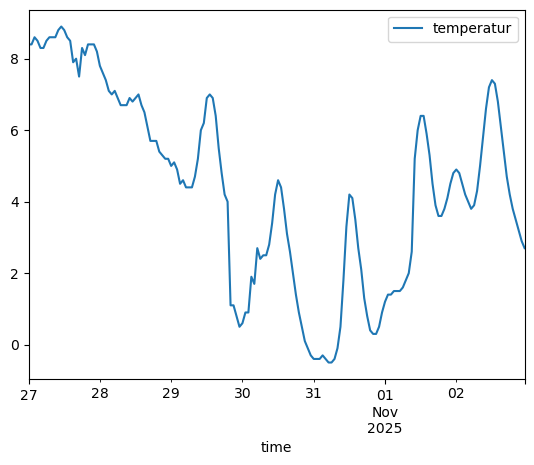

In [22]:
import pandas as pd

time = pd.to_datetime(data["hourly"]["time"])
temp = data["hourly"]["temperature_2m"]
df = pd.DataFrame({"time": time, "temperatur": temp})
df = df.set_index("time")
df.plot()

### EKSEMPEL: Eurostat

* Det er flere måter å hente data fra eurostat programmatisk
* Vi anbefaler: [denne](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-detailed-guidelines/api-statistics)
* Her får vi data på jsonstat2 format

Vi henter data med en URL av følgende format:
![https://ec.europa.eu/eurostat/documents/19009692/20123432/structure-rest-request.png/0164d56d-495a-94ec-638d-1af93be0062d?t=1728057499783](https://ec.europa.eu/eurostat/documents/19009692/20123432/structure-rest-request.png/0164d56d-495a-94ec-638d-1af93be0062d?t=1728057499783)

In [26]:
from pyjstat import pyjstat

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/tec00033"
parametre = {"format": "JSON", "lang": "EN", }

response = requests.get(url, params=parametre)
print("statuskode", response.status_code)
print("Headere (til respons)", response.headers)
print("responstype:", response.headers['content-type']) # Dersom tilgjengerlig (feks application/json)


statuskode 200
Headere (til respons) {'Date': 'Mon, 27 Oct 2025 13:49:00 GMT', 'Content-Length': '7831', 'Content-Type': 'application/json', 'Access-Control-Allow-Headers': 'Content-Type, Accept, X-Requested-With', 'Access-Control-Allow-Methods': 'GET', 'Access-Control-Allow-Origin': '*', 'Connection': 'keep-alive'}
responstype: application/json


In [88]:

data = response.text

ds = pyjstat.Dataset.read(data)
df_original = ds.write("dataframe")


<Axes: xlabel='Time'>

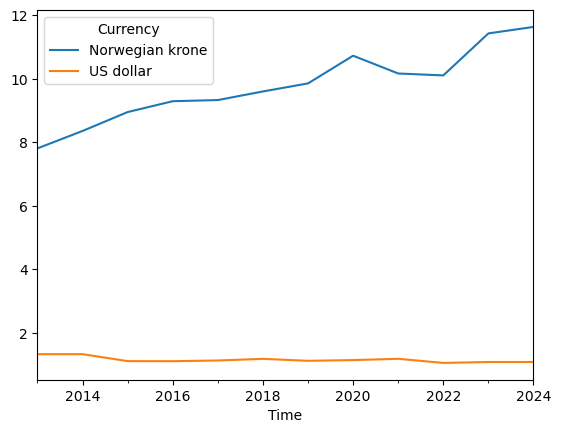

In [89]:
df = df_original
df =  df.drop(["Time frequency", "Statistical information", "Unit of measure"], axis=1)
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
df_filt = df[df["Currency"].str.contains("US dollar") | df["Currency"].str.contains("Norwegian")]

df_filt.pivot(columns="Currency", values="value").plot()